# Binomialtest – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/binomial-test)

Der **Binomialtest** prüft, ob die Häufigkeitsverteilung einer **dichotomen Variable**
(zwei Ausprägungen) einer erwarteten Verteilung entspricht.

**Wann verwenden?** Wenn du eine Variable mit genau zwei Ausprägungen hast
(Ja/Nein, Erfolg/Misserfolg, männlich/weiblich) und prüfen möchtest, ob die
beobachtete Erfolgsquote von einem bekannten Referenzwert p₀ abweicht.

**Binomialformel – Wahrscheinlichkeit für genau k Erfolge bei n Versuchen:**
$$P(X = k) = \binom{n}{k} \cdot p^k \cdot (1-p)^{n-k}$$

**p-Wert (zweiseitig):**
$$p = 2 \cdot \min\left(\sum_{i=0}^{k} P(X=i),\; \sum_{i=k}^{n} P(X=i)\right)$$

| Symbol | Bedeutung |
|---|---|
| $n$ | Stichprobengröße |
| $k$ | Beobachtete Anzahl Erfolge |
| $p_0$ | Erwartete Erfolgswahrscheinlichkeit unter H₀ |
| $\hat{p} = k/n$ | Beobachtete Erfolgsquote |

**Voraussetzungen:**
- Eine dichotome (nominale) Variable mit genau zwei Ausprägungen
- Unabhängige Beobachtungen
- Bekannter Referenzwert p₀

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from scipy.stats import binom

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Grundlage: Die Binomialverteilung

Der Binomialtest basiert auf der **Binomialverteilung**.
Sie beschreibt die Wahrscheinlichkeit, bei n Versuchen mit je der
Erfolgswahrscheinlichkeit p genau k Erfolge zu erzielen.

**Erwartungswert und Varianz:**
$$E(X) = n \cdot p, \quad \text{Var}(X) = n \cdot p \cdot (1-p)$$

**Intuition:** Ist das beobachtete k sehr unwahrscheinlich unter H₀, dann
lehnen wir H₀ ab.

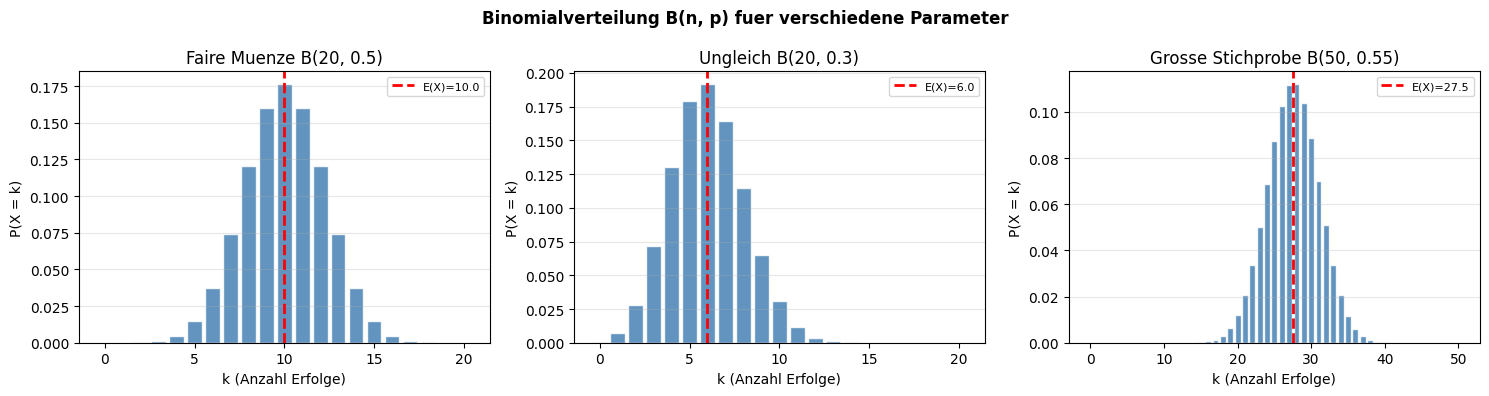

In [ ]:
# Binomialverteilung visualisieren
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Binomialverteilung B(n, p) für verschiedene Parameter",
             fontsize=12, fontweight="bold")

configs = [
    (20, 0.5,  "Faire Münze B(20, 0.5)"),
    (20, 0.3,  "Ungleich B(20, 0.3)"),
    (50, 0.55, "Grosse Stichprobe B(50, 0.55)"),
]

for ax, (n_b, p_b, titel) in zip(axes, configs):
    k_vals = np.arange(0, n_b + 1)
    probs  = binom.pmf(k_vals, n_b, p_b)
    erw    = n_b * p_b

    farben = ["steelblue"] * len(k_vals)
    ax.bar(k_vals, probs, color=farben, edgecolor="white", alpha=0.85)
    ax.axvline(erw, color="red", linestyle="--", linewidth=2,
               label="E(X)=" + str(round(erw, 1)))
    ax.set_title(titel)
    ax.set_xlabel("k (Anzahl Erfolge)")
    ax.set_ylabel("P(X = k)")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Das numiqo-Beispiel: Marketing-Studium

**Fragestellung:** Unterscheidet sich das Geschlechterverhältnis in der
Vertiefungsrichtung **Marketing** (Stichprobe) vom Frauenanteil aller
BWL-Studierenden an der Uni XY (Grundgesamtheit: **55 %**)?

**Datensatz (n = 10):**

| Marketing-Studierende | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 |
|---|---|---|---|---|---|---|---|---|---|---|
| Geschlecht | w | m | w | w | w | m | w | m | w | w |

- Beobachtete Frauen: k = 7 von n = 10
- Beobachtete Quote: $\hat{p}$ = 0,70
- Erwartete Quote unter H₀: p₀ = 0,55

**numiqo-Ergebnis:**
- p-Wert (zweiseitig) = 0,528 → **nicht signifikant**
- H₀ wird beibehalten

In [10]:
# numiqo-Datensatz: Geschlecht Marketing-Studium
daten_raw = ["weiblich", "männlich", "weiblich", "weiblich", "weiblich",
             "männlich", "weiblich", "männlich", "weiblich", "weiblich"]
n_b    = len(daten_raw)
k_b    = daten_raw.count("weiblich")   # Erfolge = weiblich
p_null = 0.55                          # Frauenanteil gesamt BWL
p_hat  = k_b / n_b                    # beobachtete Quote

print("numiqo-Hauptbeispiel: Marketing-Studium")
print(f"H0: p = {p_null}  (Frauenanteil entspricht BWL-Durchschnitt)")
print(f"H1: p != {p_null} (Frauenanteil weicht ab)  [zweiseitig]")
print()
print(f"n:                {n_b}")
print(f"k (Frauen):       {k_b}")
print(f"Beob. Quote p_hat:{p_hat:.4f} ({p_hat*100:.1f}%)")
print(f"Erw.  Quote p0:   {p_null:.4f} ({p_null*100:.1f}%)")
print()

# Binomialtest (scipy)
ergebnis = stats.binomtest(k_b, n_b, p_null, alternative="two-sided")
p_wert   = ergebnis.pvalue

print(f"p-Wert (zweiseitig): {p_wert:.4f}  (numiqo: 0,528)")
print()
alpha = 0.05
if p_wert < alpha:
    print(f"p={p_wert:.4f} < {alpha} -> H0 ABGELEHNT")
    print("Signifikanter Unterschied zum BWL-Durchschnitt!")
else:
    print(f"p={p_wert:.4f} >= {alpha} -> H0 nicht abgelehnt")
    print("Kein signifikanter Unterschied zum BWL-Durchschnitt.")

# Konfidenzintervall für p
ki = ergebnis.proportion_ci(confidence_level=0.95, method="exact")
print()
print(f"95%-KI für p: [{ki.low:.4f}, {ki.high:.4f}]")

numiqo-Hauptbeispiel: Marketing-Studium
H0: p = 0.55  (Frauenanteil entspricht BWL-Durchschnitt)
H1: p != 0.55 (Frauenanteil weicht ab)  [zweiseitig]

n:                10
k (Frauen):       7
Beob. Quote p_hat:0.7000 (70.0%)
Erw.  Quote p0:   0.5500 (55.0%)

p-Wert (zweiseitig): 0.5276  (numiqo: 0,528)

p=0.5276 >= 0.05 -> H0 nicht abgelehnt
Kein signifikanter Unterschied zum BWL-Durchschnitt.

95%-KI für p: [0.3475, 0.9333]


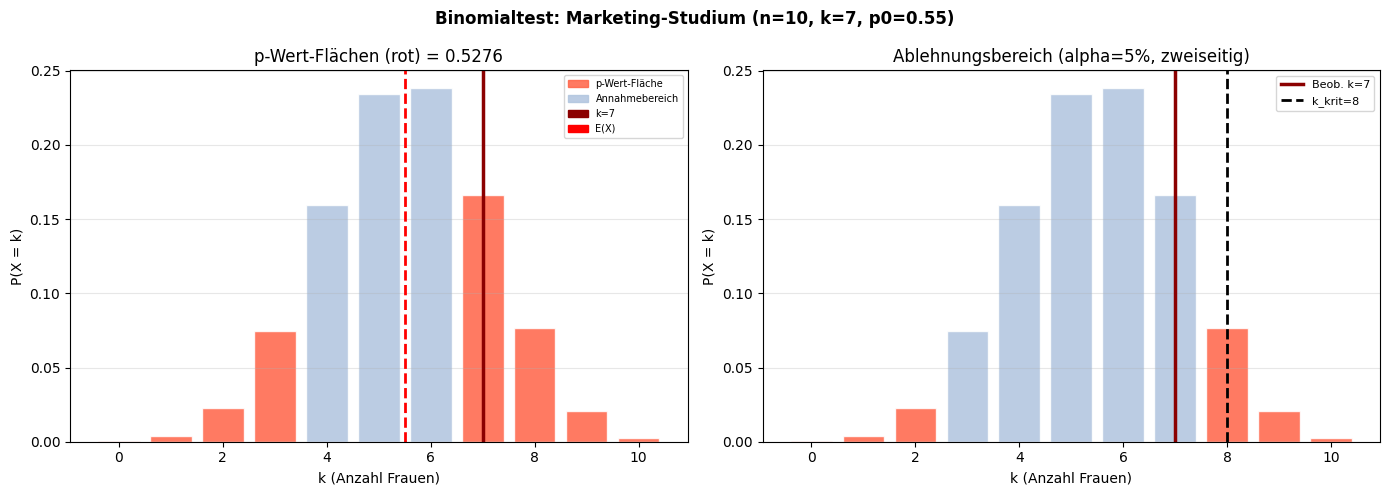

In [ ]:
# Visualisierung des p-Werts auf der Binomialverteilung
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Binomialtest: Marketing-Studium (n=10, k=7, p0=0.55)",
             fontsize=12, fontweight="bold")

k_vals = np.arange(0, n_b + 1)
probs  = binom.pmf(k_vals, n_b, p_null)

# Flaechenanteile für p-Wert (zweiseitig)
# P(X >= 7) + P(X <= n - 7) analog zur Spiegelung
p_rechts  = binom.sf(k_b - 1, n_b, p_null)   # P(X >= 7)
p_links   = binom.cdf(n_b - k_b, n_b, p_null) # P(X <= 3)  gespiegelt
# scipy binomtest macht das exakt:

farben_b = []
for k in k_vals:
    if k >= k_b or k <= (n_b - k_b):
        farben_b.append("tomato")
    else:
        farben_b.append("lightsteelblue")

axes[0].bar(k_vals, probs, color=farben_b, edgecolor="white", alpha=0.85)
axes[0].axvline(k_b,          color="darkred",   linewidth=2.5,
                label="Beob. k=" + str(k_b))
axes[0].axvline(n_b * p_null, color="red",       linewidth=2, linestyle="--",
                label="E(X) = n*p0 = " + str(n_b * p_null))
axes[0].set_title("p-Wert-Flächen (rot) = " + str(round(p_wert, 4)))
axes[0].set_xlabel("k (Anzahl Frauen)")
axes[0].set_ylabel("P(X = k)")
axes[0].legend(fontsize=8)
axes[0].grid(axis="y", alpha=0.3)

tomato_p = mpatches.Patch(color="tomato",       alpha=0.85, label="p-Wert-Fläche")
blau_p   = mpatches.Patch(color="lightsteelblue", alpha=0.85, label="Annahmebereich")
axes[0].legend(handles=[tomato_p, blau_p,
    mpatches.Patch(color="darkred", label="k="+str(k_b)),
    mpatches.Patch(color="red",     label="E(X)")], fontsize=7)

# Kumulierte Verteilung mit Ablehnungsbereich
k_krit_o = binom.ppf(0.975, n_b, p_null)
k_krit_u = binom.ppf(0.025, n_b, p_null)
farben2  = ["tomato" if (k <= k_krit_u or k >= k_krit_o) else "lightsteelblue"
            for k in k_vals]

axes[1].bar(k_vals, probs, color=farben2, edgecolor="white", alpha=0.85)
axes[1].axvline(k_b,    color="darkred", linewidth=2.5, label="Beob. k=" + str(k_b))
axes[1].axvline(k_krit_o, color="black", linewidth=2, linestyle="--",
                label="k_krit=" + str(int(k_krit_o)))
axes[1].set_title("Ablehnungsbereich (alpha=5%, zweiseitig)")
axes[1].set_xlabel("k (Anzahl Frauen)")
axes[1].set_ylabel("P(X = k)")
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Schritt-für-Schritt-Berechnung

1. **Hypothesen formulieren** – p₀ festlegen, gerichtet/ungerichtet?
2. **Beobachtungen zählen** – k Erfolge aus n Versuchen
3. **p-Wert berechnen** – aus der Binomialverteilung
4. **Entscheidung** – p < α → H₀ ablehnen

**Manuell für das numiqo-Beispiel:**

$$P(X = 7 \mid n=10, p=0{,}55) = \binom{10}{7} \cdot 0{,}55^7 \cdot 0{,}45^3 = 120 \cdot 0{,}01522 \cdot 0{,}09113 \approx 0{,}166$$

Der p-Wert (zweiseitig) summiert alle Wahrscheinlichkeiten, die mindestens so
extrem wie k=7 sind.

In [12]:
# Manuelle Berechnung
from math import comb, factorial

print("Manuelle Berechnung: Marketing-Beispiel")
print()
print(f"Eingaben: n={n_b}, k={k_b}, p0={p_null}")
print()

# P(X=7) manuell
binom_koeff = comb(n_b, k_b)
p_k         = (p_null**k_b) * ((1-p_null)**(n_b-k_b))
p_xgleich_k = binom_koeff * p_k
print(f"P(X=7) = C(10,7) * 0.55^7 * 0.45^3")
print(f"       = {binom_koeff} * {p_null**k_b:.6f} * {(1-p_null)**(n_b-k_b):.6f}")
print(f"       = {p_xgleich_k:.6f}")
print()

# P-Wert zweiseitig: alle k mit P(X=k) <= P(X=7)
print("p-Wert (zweiseitig): Summe aller P(X=k) <= P(X=beob):")
p_grenze = binom.pmf(k_b, n_b, p_null)
p_summe  = 0.0
print(f"{'k':>4}  {'P(X=k)':>10}  {'<= P(X=7)?':>12}  {'berechnet':>10}")
for k in range(n_b + 1):
    pk = binom.pmf(k, n_b, p_null)
    benutzt = pk <= p_grenze + 1e-10
    if benutzt:
        p_summe += pk
    print(f"{k:>4}  {pk:>10.6f}  {str(benutzt):>12}  {pk if benutzt else 0:>10.6f}")

print()
print(f"p-Wert (manuell):    {p_summe:.4f}")
print(f"p-Wert (scipy):      {p_wert:.4f}")
print(f"Unterschied:         {abs(p_summe - p_wert):.6f}")

Manuelle Berechnung: Marketing-Beispiel

Eingaben: n=10, k=7, p0=0.55

P(X=7) = C(10,7) * 0.55^7 * 0.45^3
       = 120 * 0.015224 * 0.091125
       = 0.166478

p-Wert (zweiseitig): Summe aller P(X=k) <= P(X=beob):
   k      P(X=k)    <= P(X=7)?   berechnet
   0    0.000341          True    0.000341
   1    0.004162          True    0.004162
   2    0.022890          True    0.022890
   3    0.074603          True    0.074603
   4    0.159568          True    0.159568
   5    0.234033         False    0.000000
   6    0.238367         False    0.000000
   7    0.166478          True    0.166478
   8    0.076303          True    0.076303
   9    0.020724          True    0.020724
  10    0.002533          True    0.002533

p-Wert (manuell):    0.5276
p-Wert (scipy):      0.5276
Unterschied:         0.000000


## 4. Einseitiger und zweiseitiger Binomialtest

| | Zweiseitig | Einseitig links | Einseitig rechts |
|---|---|---|---|
| **H₁** | p ≠ p₀ | p < p₀ | p > p₀ |
| **Wann?** | Richtung unbekannt | Erwartet kleinere Quote | Erwartet größere Quote |
| **p-Wert** | Beide Seiten | Nur linke Seite | Nur rechte Seite |

Beispiel: 14 Köpfe bei 20 Münzwürfen (H0: p=0.5)
n=20, k=14, p_hat=0.70, p0=0.5

Zweiseitig  (H1: p != 0.5):  p = 0.1153 -> n.s.
Einseitig > (H1: p > 0.5):   p = 0.0577 -> n.s.
Einseitig < (H1: p < 0.5):   p = 0.9793 -> n.s.


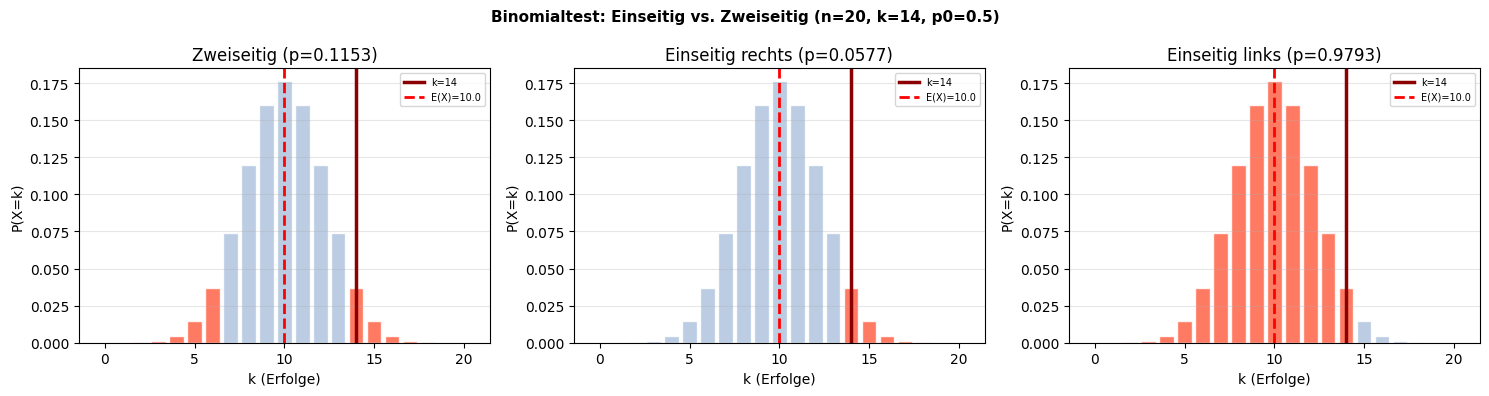

In [11]:
# Alle drei Testrichtungen vergleichen
n_e, k_e, p0_e = 20, 14, 0.5  # 14 Koöpfe von 20 Münzwürfen, faire Münze?

r_zwei   = stats.binomtest(k_e, n_e, p0_e, alternative="two-sided")
r_rechts = stats.binomtest(k_e, n_e, p0_e, alternative="greater")
r_links  = stats.binomtest(k_e, n_e, p0_e, alternative="less")

print("Beispiel: 14 Köpfe bei 20 Münzwürfen (H0: p=0.5)")
print(f"n={n_e}, k={k_e}, p_hat={k_e/n_e:.2f}, p0={p0_e}")
print()
print(f"Zweiseitig  (H1: p != 0.5):  p = {r_zwei.pvalue:.4f}"
      + (" -> signifikant!" if r_zwei.pvalue < 0.05 else " -> n.s."))
print(f"Einseitig > (H1: p > 0.5):   p = {r_rechts.pvalue:.4f}"
      + (" -> signifikant!" if r_rechts.pvalue < 0.05 else " -> n.s."))
print(f"Einseitig < (H1: p < 0.5):   p = {r_links.pvalue:.4f}"
      + (" -> signifikant!" if r_links.pvalue < 0.05 else " -> n.s."))

# Visualisierung
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Binomialtest: Einseitig vs. Zweiseitig (n=20, k=14, p0=0.5)",
             fontsize=11, fontweight="bold")

k_vals2 = np.arange(0, n_e + 1)
probs2  = binom.pmf(k_vals2, n_e, p0_e)
p_k14   = binom.pmf(k_e, n_e, p0_e)

masken = [
    [pk <= p_k14 + 1e-10 for pk in probs2],
    [k >= k_e for k in k_vals2],
    [k <= k_e for k in k_vals2],
]
titel_list = [
    "Zweiseitig (p=" + str(round(r_zwei.pvalue, 4)) + ")",
    "Einseitig rechts (p=" + str(round(r_rechts.pvalue, 4)) + ")",
    "Einseitig links (p=" + str(round(r_links.pvalue, 4)) + ")",
]

for ax, maske, titel in zip(axes, masken, titel_list):
    farben_m = ["tomato" if m else "lightsteelblue" for m in maske]
    ax.bar(k_vals2, probs2, color=farben_m, edgecolor="white", alpha=0.85)
    ax.axvline(k_e, color="darkred", linewidth=2.5,
               label="k=" + str(k_e))
    ax.axvline(n_e * p0_e, color="red", linewidth=2, linestyle="--",
               label="E(X)=" + str(n_e * p0_e))
    ax.set_title(titel)
    ax.set_xlabel("k (Erfolge)")
    ax.set_ylabel("P(X=k)")
    ax.legend(fontsize=7)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Weitere Beispiele

### Münzwurf: Fair oder gezinkt?
Eine Münze wird 30 Mal geworfen. Bei einer fairen Münze erwartet man 50 % Kopf.

### Produktionskontrolle: Ausschussquote
In einer Fabrik soll die Ausschussquote unter 5 % liegen.
In einer Stichprobe von 100 Teilen finden sich 8 fehlerhafte.

### Wahlprognose: Hat Kandidat A Mehrheit?
Eine Umfrage zeigt 54 von 100 Personen für Kandidat A.
Laut letzter Wahl lag er bei 48 %.

Weitere Binomialtest-Beispiele
Münzwurf: fair? (k=20 Kopf, n=30)
  n=30, k=20, p_hat=0.667, p0=0.5
  p-Wert (two-sided): 0.0987 -> n.s.
  95%-KI: [0.472, 0.827]
Ausschuss: > 5%? (k=8 fehlerh., n=100)
  n=100, k=8, p_hat=0.080, p0=0.05
  p-Wert (greater): 0.1280 -> n.s.
  95%-KI: [0.040, 1.000]
Wahl: Mehrheit? (k=54/100, p0=0.48)
  n=100, k=54, p_hat=0.540, p0=0.48
  p-Wert (greater): 0.1355 -> n.s.
  95%-KI: [0.453, 1.000]


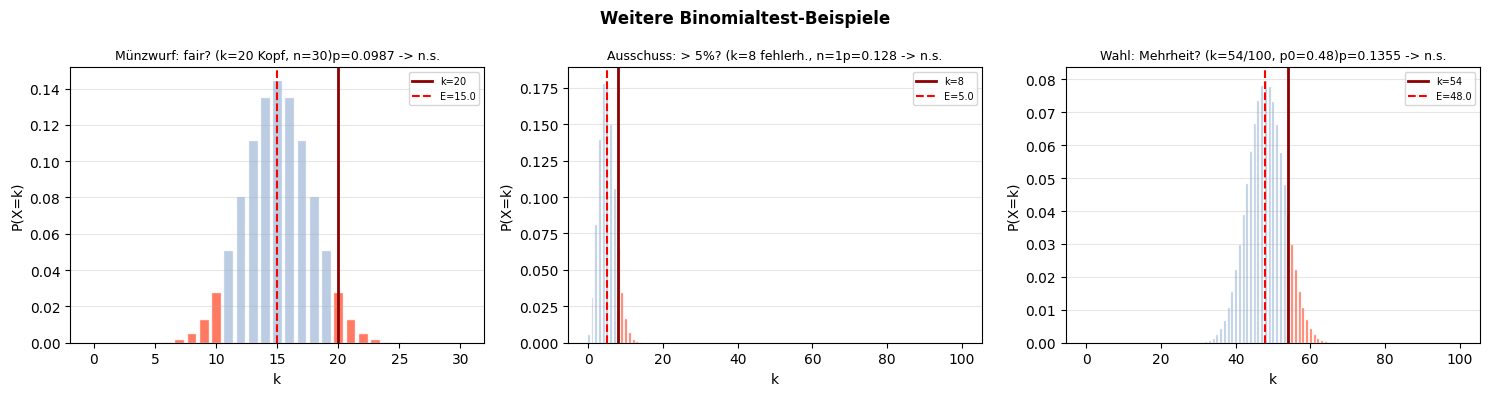

In [13]:
beispiele = [
    (30, 20, 0.5,  "two-sided", "Münzwurf: fair? (k=20 Kopf, n=30)"),
    (100, 8, 0.05, "greater",   "Ausschuss: > 5%? (k=8 fehlerh., n=100)"),
    (100, 54, 0.48, "greater",  "Wahl: Mehrheit? (k=54/100, p0=0.48)"),
]

print("Weitere Binomialtest-Beispiele")
for n_x, k_x, p0_x, alt, beschr in beispiele:
    r_x = stats.binomtest(k_x, n_x, p0_x, alternative=alt)
    ki_x = r_x.proportion_ci(confidence_level=0.95, method="exact")
    sig = "signifikant" if r_x.pvalue < 0.05 else "n.s."
    print(f"{beschr}")
    print(f"  n={n_x}, k={k_x}, p_hat={k_x/n_x:.3f}, p0={p0_x}")
    print(f"  p-Wert ({alt}): {r_x.pvalue:.4f} -> {sig}")
    print(f"  95%-KI: [{ki_x.low:.3f}, {ki_x.high:.3f}]")

# Visualisierung
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Weitere Binomialtest-Beispiele", fontsize=12, fontweight="bold")

for ax, (n_x, k_x, p0_x, alt, beschr) in zip(axes, beispiele):
    r_x = stats.binomtest(k_x, n_x, p0_x, alternative=alt)
    k_range = np.arange(0, n_x + 1)
    probs_x = binom.pmf(k_range, n_x, p0_x)
    p_k_x   = binom.pmf(k_x, n_x, p0_x)

    if alt == "two-sided":
        mask_x = [binom.pmf(k, n_x, p0_x) <= p_k_x + 1e-10 for k in k_range]
    elif alt == "greater":
        mask_x = [k >= k_x for k in k_range]
    else:
        mask_x = [k <= k_x for k in k_range]

    farben_x = ["tomato" if m else "lightsteelblue" for m in mask_x]
    ax.bar(k_range, probs_x, color=farben_x, edgecolor="white", alpha=0.85)
    ax.axvline(k_x,       color="darkred", linewidth=2,
               label="k=" + str(k_x))
    ax.axvline(n_x*p0_x,  color="red",    linewidth=1.5, linestyle="--",
               label="E=" + str(round(n_x*p0_x, 1)))
    sig_x = "sig." if r_x.pvalue < 0.05 else "n.s."
    ax.set_title(beschr[:35] + "p=" + str(round(r_x.pvalue, 4)) + " -> " + sig_x,
                 fontsize=9)
    ax.set_xlabel("k")
    ax.set_ylabel("P(X=k)")
    ax.legend(fontsize=7)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# Wiederverwendbare Binomialtest-Funktion
def binomialtest_apa(n_f, k_f, p0_f, alternative="two-sided",
                     erfolg_name="Erfolg", alpha=0.05):
    r_f  = stats.binomtest(k_f, n_f, p0_f, alternative=alternative)
    ki_f = r_f.proportion_ci(confidence_level=0.95, method="exact")
    p_hat_f = k_f / n_f
    sig_f   = "signifikant" if r_f.pvalue < alpha else "NICHT signifikant"

    p_str = "p < .001" if r_f.pvalue < 0.001 else (
            "p = " + str(round(r_f.pvalue, 3)).replace("0.", "."))

    print(f"Binomialtest: {erfolg_name}")
    print(f"H0: p = {p0_f}  |  H1: p {'!=' if alternative=='two-sided' else ('>' if alternative=='greater' else '<')} {p0_f}")
    print(f"n={n_f}, k={k_f}, p_hat={p_hat_f:.4f}")
    print()
    print(f"Binomialtest: {p_str}  ({sig_f})")
    print(f"95%-KI fuer p: [{ki_f.low:.4f}, {ki_f.high:.4f}]")
    print()
    if r_f.pvalue < alpha:
        print("H0 wird abgelehnt.")
        print("Die beobachtete Häufigkeitsverteilung weicht signifikant von p0 ab.")
    else:
        print("H0 wird nicht abgelehnt.")
        print("Kein signifikanter Unterschied zur erwarteten Verteilung.")
    print()


# numiqo-Hauptbeispiel
binomialtest_apa(10, 7, 0.55, "two-sided", "Frauenanteil Marketing")
print()
# Muenzwurf
binomialtest_apa(30, 20, 0.5, "two-sided", "Muenzwurf Kopf")
print()
# Ausschuss
binomialtest_apa(100, 8, 0.05, "greater", "Ausschussquote")

Binomialtest: Frauenanteil Marketing
H0: p = 0.55  |  H1: p != 0.55
n=10, k=7, p_hat=0.7000

Binomialtest: p = .528  (NICHT signifikant)
95%-KI fuer p: [0.3475, 0.9333]

H0 wird nicht abgelehnt.
Kein signifikanter Unterschied zur erwarteten Verteilung.


Binomialtest: Muenzwurf Kopf
H0: p = 0.5  |  H1: p != 0.5
n=30, k=20, p_hat=0.6667

Binomialtest: p = .099  (NICHT signifikant)
95%-KI fuer p: [0.4719, 0.8271]

H0 wird nicht abgelehnt.
Kein signifikanter Unterschied zur erwarteten Verteilung.


Binomialtest: Ausschussquote
H0: p = 0.05  |  H1: p > 0.05
n=100, k=8, p_hat=0.0800

Binomialtest: p = .128  (NICHT signifikant)
95%-KI fuer p: [0.0404, 1.0000]

H0 wird nicht abgelehnt.
Kein signifikanter Unterschied zur erwarteten Verteilung.



## 6. Zusammenfassung

```
Binomialtest – Übersicht
│
├── WANN?
│   Dichotome Variable (2 Auspraeungen: Ja/Nein, Erfolg/Misserfolg)
│   Frage: Weicht die Erfolgsquote von einem bekannten p0 ab?
│
├── VORAUSSETZUNGEN
│   1. Dichotome nominale Variable
│   2. Unabhängige Beobachtungen
│   3. Bekannter Referenzwert p0
│
├── HYPOTHESEN
│   Zweiseitig:       H0: p = p0  vs.  H1: p != p0
│   Einseitig rechts: H0: p <= p0 vs.  H1: p > p0
│   Einseitig links:  H0: p >= p0 vs.  H1: p < p0
│
├── BERECHNUNG
│   P(X=k) = C(n,k) * p0^k * (1-p0)^(n-k)
│   p-Wert (zweiseitig): Summe aller P(X=k) <= P(X=beob)
│
├── ERGEBNIS
│   p < alpha  -> H0 ablehnen: Häufigkeit weicht signifikant ab
│   p >= alpha -> H0 behalten: kein sign. Unterschied zu p0
│   + 95%-KI fuer den wahren Anteil p
│
├── BEISPIELE
│   Marketing-Frauenanteil (70% vs. erwartet 55%): n.s.
│   Muenzwurf (67% Kopf vs. 50%): signifikant
│   Ausschussquote (8% vs. erwartet 5%): signifikant
│
└── PYTHON
    scipy.stats.binomtest(k, n, p0, alternative="two-sided")
    -> .pvalue, .proportion_ci()
```

---
Quelle: [numiqo.de/tutorial/binomial-test](https://numiqo.de/tutorial/binomial-test)